# Task 1: Data preparation

### 1A: Exploratory data analysis

In [1]:
# import packages
import numpy as np
import pandas as pd
import seaborn as sb

import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-pastel')

In [2]:
df_mood = pd.read_csv('dataset_mood_smartphone.csv')
df_mood

,Unnamed: 0,id,time,variable,value
0,1,AS14.01,2014-02-26 13:00:00.000,mood,6.000
1,2,AS14.01,2014-02-26 15:00:00.000,mood,6.000
2,3,AS14.01,2014-02-26 18:00:00.000,mood,6.000
3,4,AS14.01,2014-02-26 21:00:00.000,mood,7.000
4,5,AS14.01,2014-02-27 09:00:00.000,mood,6.000
...,...,...,...,...,...
376907,2770399,AS14.30,2014-04-11 07:51:16.948,appCat.weather,8.032
376908,2772465,AS14.30,2014-04-19 11:00:32.747,appCat.weather,3.008
376909,2774026,AS14.30,2014-04-26 10:19:07.434,appCat.weather,7.026
376910,2774133,AS14.30,2014-04-27 00:44:48.450,appCat.weather,23.033


In [3]:
print(df_mood.id.unique())

time_measures = []
for id in df_mood.id.unique():
    id_df = df_mood[df_mood.id == id]
    time_measures.append(len(id_df.time.unique()))

print(sorted(time_measures))

<StringArray>
['AS14.01', 'AS14.02', 'AS14.03', 'AS14.05', 'AS14.06', 'AS14.07', 'AS14.08',
 'AS14.09', 'AS14.12', 'AS14.13', 'AS14.14', 'AS14.15', 'AS14.16', 'AS14.17',
 'AS14.19', 'AS14.20', 'AS14.23', 'AS14.24', 'AS14.25', 'AS14.26', 'AS14.27',
 'AS14.28', 'AS14.29', 'AS14.30', 'AS14.31', 'AS14.32', 'AS14.33']
Length: 27, dtype: str
[2270, 3096, 3429, 6829, 8743, 10321, 10689, 10795, 11055, 12188, 13657, 13738, 13939, 14100, 15023, 15133, 15474, 15490, 15777, 16434, 16716, 16809, 17334, 18720, 18884, 20985, 21298]


In [4]:
df_mood.variable.unique()

<StringArray>
[                'mood',   'circumplex.arousal',   'circumplex.valence',
             'activity',               'screen',                 'call',
                  'sms',       'appCat.builtin', 'appCat.communication',
 'appCat.entertainment',       'appCat.finance',          'appCat.game',
        'appCat.office',         'appCat.other',        'appCat.social',
        'appCat.travel',       'appCat.unknown',     'appCat.utilities',
       'appCat.weather']
Length: 19, dtype: str

#### 1A.1 Ranges of values

In [5]:
for variable in df_mood.variable.unique():
    var_df = df_mood[df_mood.variable == variable]
    print(f'{variable}, min: {sorted(var_df.value)[0]}, max: {sorted(var_df.value)[-1]}')

mood, min: 1.0, max: 10.0
circumplex.arousal, min: -2.0, max: 2.0
circumplex.valence, min: -2.0, max: 2.0
activity, min: 0.0, max: 1.0
screen, min: 0.0350000858306885, max: 9867.00699996948
call, min: 1.0, max: 1.0
sms, min: 1.0, max: 1.0
appCat.builtin, min: -82798.871, max: 33960.246
appCat.communication, min: 0.006, max: 9830.777
appCat.entertainment, min: -0.011, max: 32148.677
appCat.finance, min: 0.131, max: 355.513
appCat.game, min: 1.003, max: 5491.793
appCat.office, min: 0.003, max: 32708.818
appCat.other, min: 0.014, max: 3892.038
appCat.social, min: 0.094, max: 30000.906
appCat.travel, min: 0.08, max: 10452.615
appCat.unknown, min: 0.111, max: 2239.937
appCat.utilities, min: 0.246, max: 1802.649
appCat.weather, min: 1.003, max: 344.863


#### 1A.2 Missing values

In [6]:
# check whether there are any missing values in not 'value' column
df_mood.info()
# only in the last column, there are missing values
# 376912 - 376710 = 202 missing values

<class 'pandas.DataFrame'>
RangeIndex: 376912 entries, 0 to 376911
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Unnamed: 0  376912 non-null  int64  
 1   id          376912 non-null  str    
 2   time        376912 non-null  str    
 3   variable    376912 non-null  str    
 4   value       376710 non-null  float64
dtypes: float64(1), int64(1), str(3)
memory usage: 14.4 MB


[np.int64(0), np.int64(46), np.int64(156), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]
202


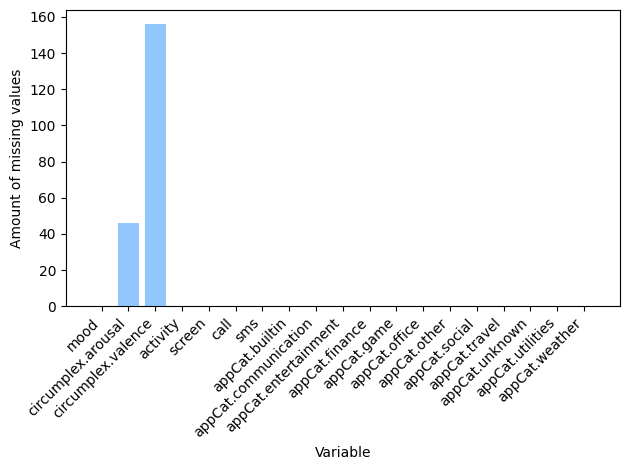

In [7]:
# missing values per variable
variables = df_mood.variable.unique()
missing = []
for variable in variables:
    var_df = df_mood[df_mood.variable == variable]
    missing.append(var_df["value"].isnull().sum())

# missing list adds up to 202:
print(missing)
print(sum(missing))

# plot distribution for this

fig, ax = plt.subplots()

ax.bar(variables, missing)
ax.set_ylabel("Amount of missing values")
ax.set_xlabel("Variable")
ax.tick_params("x", rotation = 45)

plt.setp(ax.get_xticklabels(), ha = "right")
plt.tight_layout()

    

202


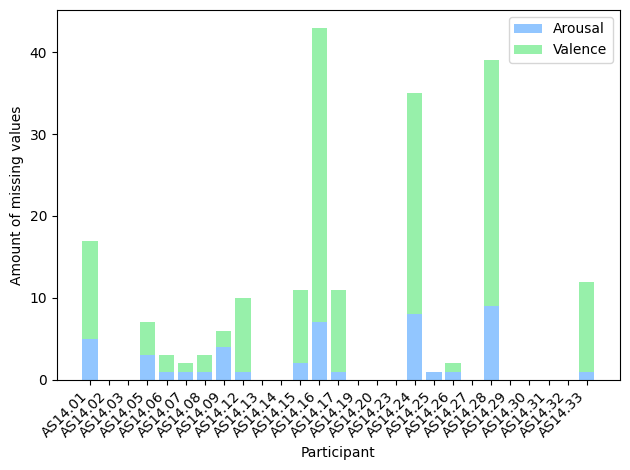

In [8]:
# missing values per participant
ids = df_mood.id.unique()
missing = []

missing_counts = {'Arousal': [], 'Valence': []}

for id in ids:
    #define df for this id
    id_df = df_mood[df_mood.id == id]

    # count missing values in arousal
    id_arouse_df = id_df[id_df.variable == 'circumplex.arousal']
    missing_counts['Arousal'].append(id_arouse_df["value"].isnull().sum())

    #count missing values in valence
    id_valence_df = id_df[id_df.variable == 'circumplex.valence']
    missing_counts['Valence'].append(id_valence_df['value'].isnull().sum())
   
# missing list adds up to 202:
print(sum(missing_counts['Arousal']) + sum(missing_counts['Valence']))

# plot distribution for this

fig, ax = plt.subplots()
bottom = np.zeros(len(ids))

for variable, counts in missing_counts.items():
    p = ax.bar(ids, counts, label = variable, bottom = bottom)
    bottom += counts
    # ax.bar_label(p, label_type = 'center')

# ax.bar(ids, missing)
ax.set_ylabel("Amount of missing values")
ax.set_xlabel("Participant")
ax.tick_params("x", rotation = 45)
ax.legend()

plt.setp(ax.get_xticklabels(), ha = "right")
plt.tight_layout()

#### 1A.3 Distribution of values

Text(0, 0.5, 'count')

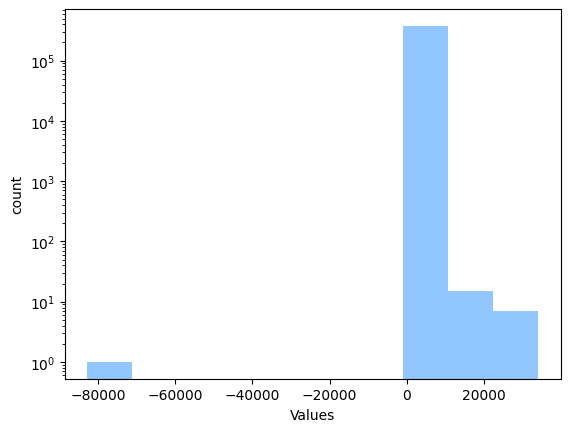

In [9]:
# disribution of all values 

fig, ax = plt.subplots()
ax.hist(df_mood.value)
ax.set_yscale('log', base = 10)
ax.set_xlabel(f'Values')
ax.set_ylabel('count')

Text(0, 0.5, 'Count')

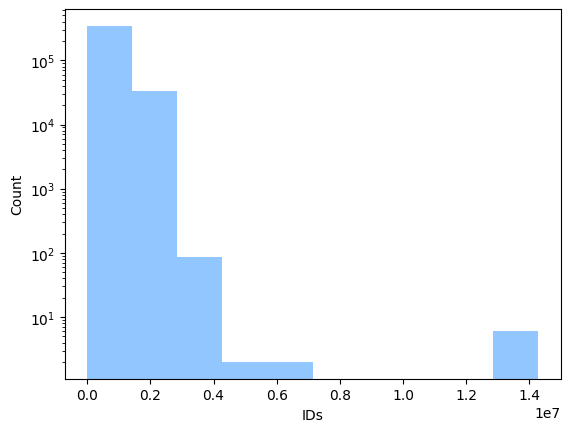

In [10]:
# distribution of ids

fig, ax = plt.subplots()
ax.hist(df_mood["Unnamed: 0"])
ax.set_yscale('log', base = 10)
ax.set_xlabel(f'IDs')
ax.set_ylabel('Count')

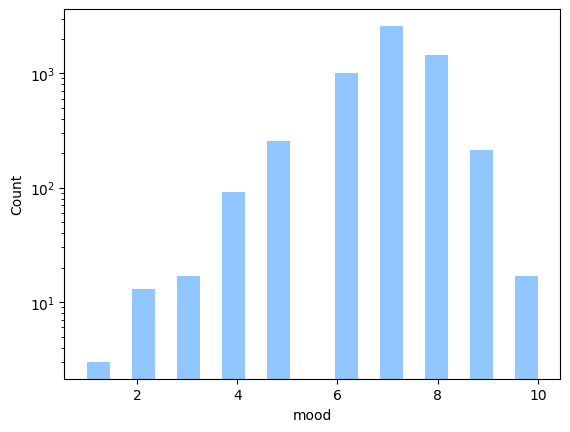

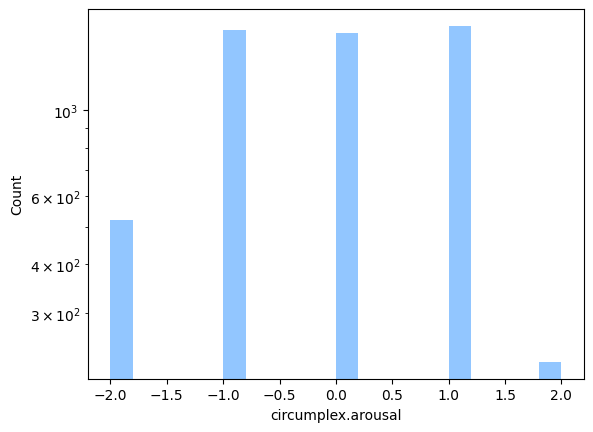

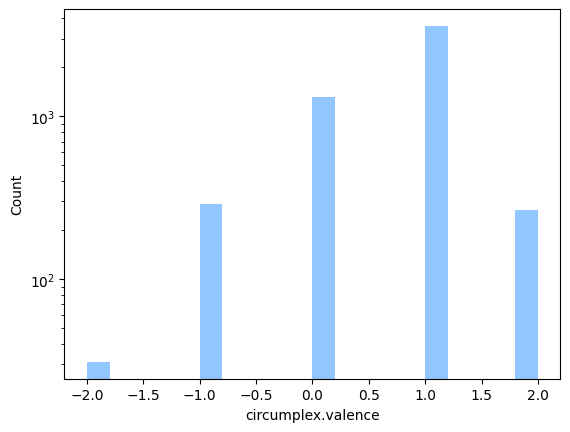

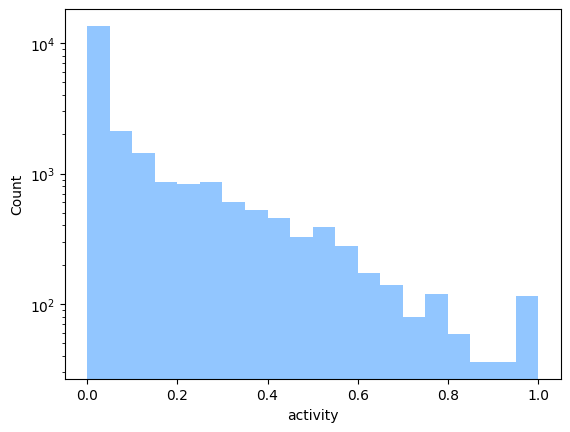

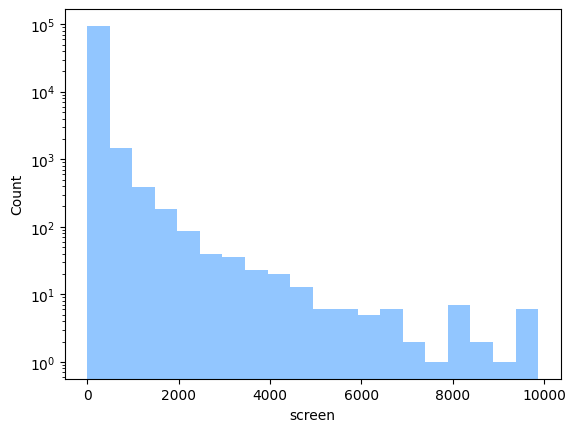

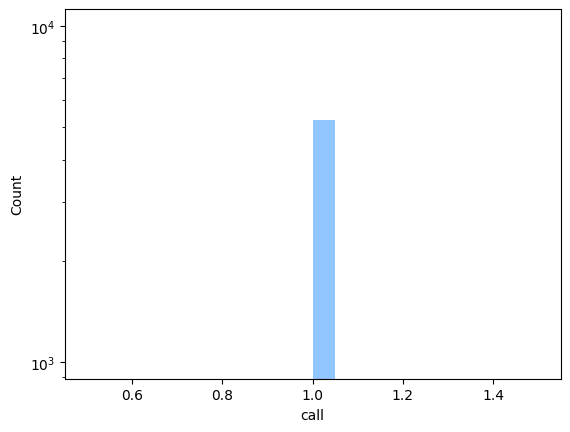

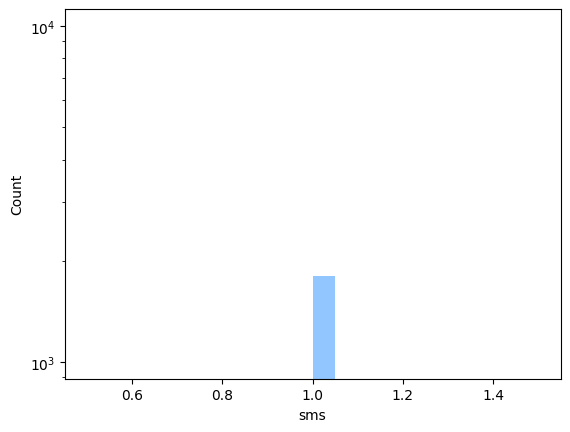

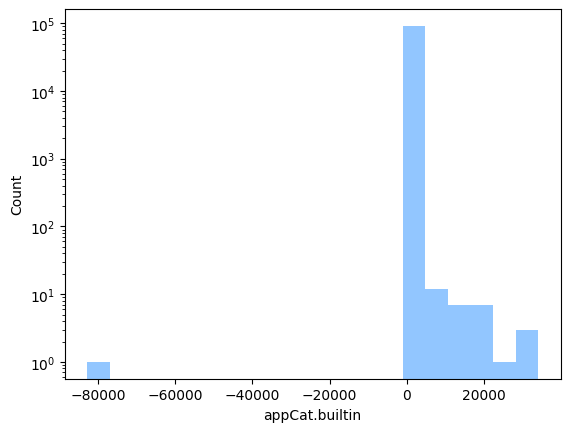

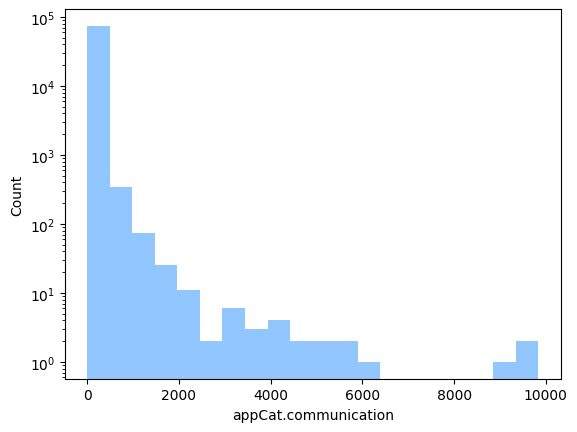

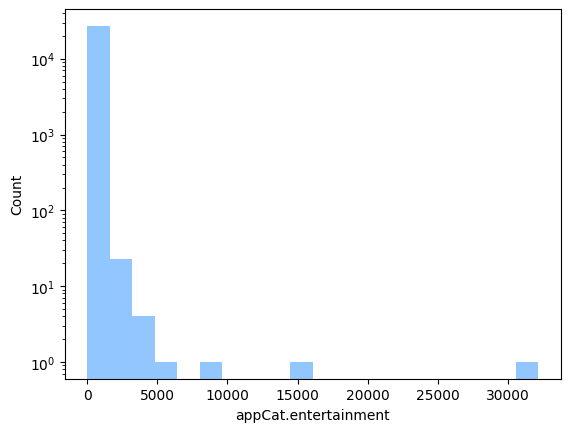

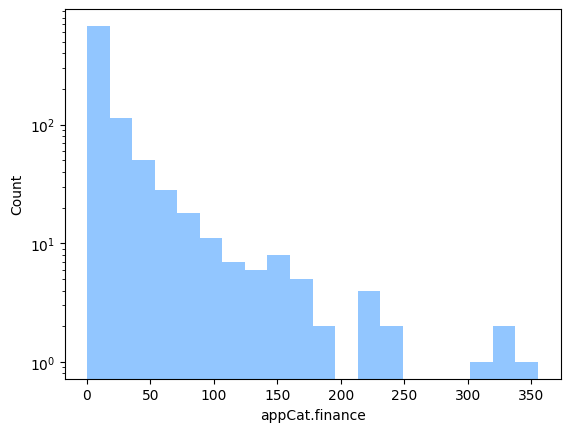

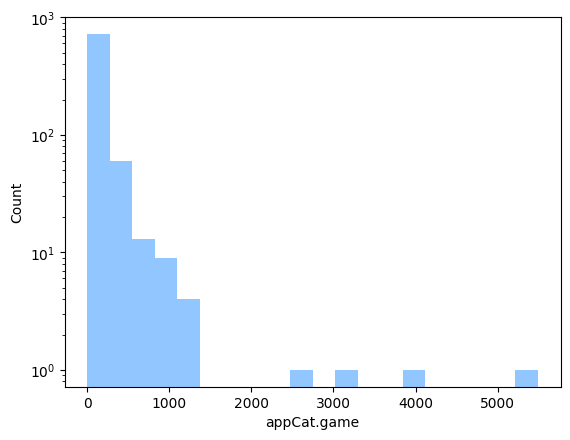

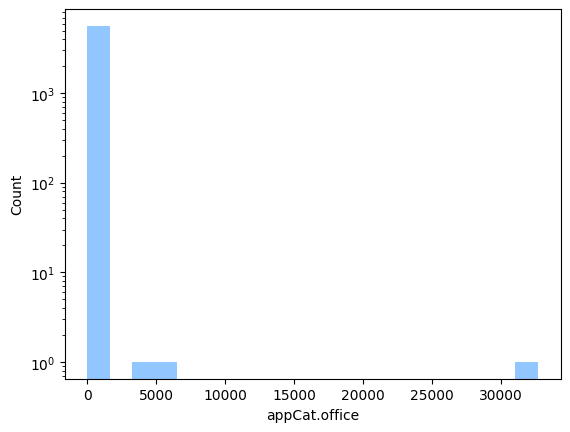

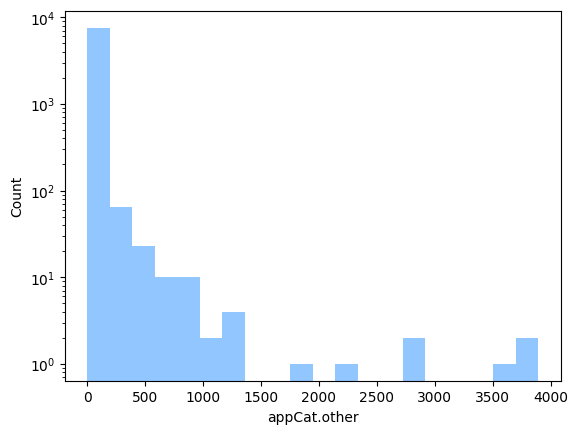

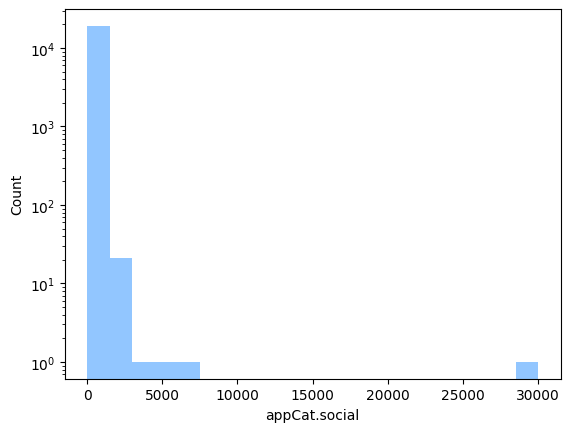

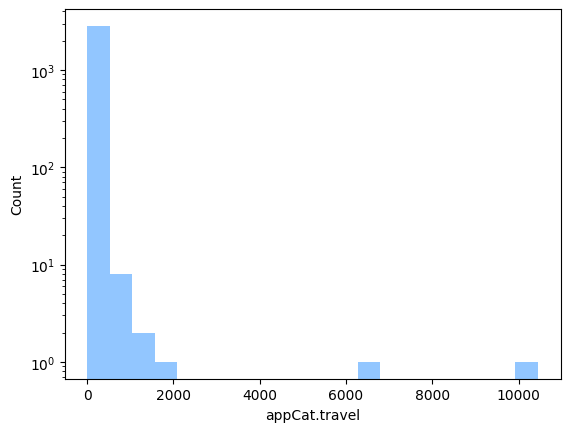

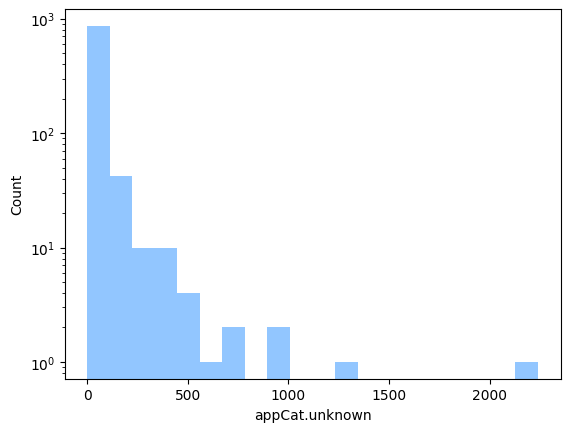

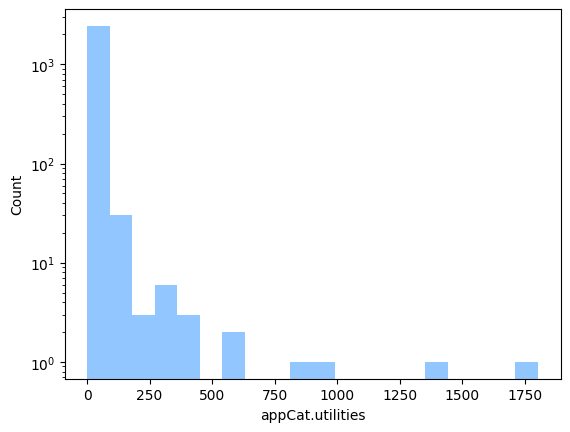

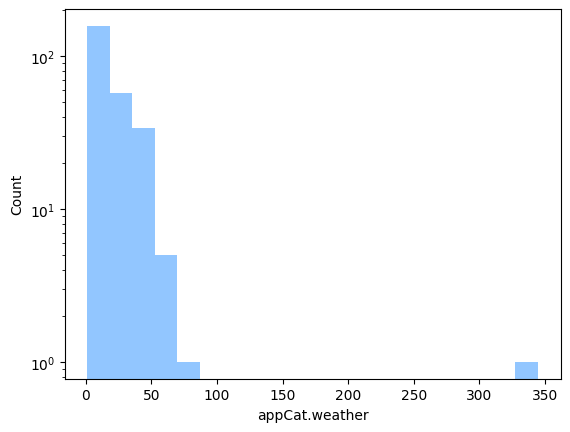

In [11]:
# distribution of values for each variable
for variable in df_mood.variable.unique():
    var_df = df_mood[df_mood.variable == variable]

    fig, ax = plt.subplots()
    ax.hist(var_df.value, bins = 20)
    ax.set_yscale('log', base = 10)
    ax.set_xlabel(f'{variable}')
    ax.set_ylabel('Count')

#### 1A.4 Relationships between attributes

In [12]:
# remove unusual instances before we do correlation testing
builtin = [-82798.871, -44.689, -1.218]
entertain = [-0.011]

# print(df_mood.loc[df_mood['value'] == builtin[0]])
# print(df_mood.loc[df_mood['value'] == builtin[1]])
# print(df_mood.loc[df_mood['value'] == builtin[2]])
# print(df_mood.loc[df_mood['value'] == entertain])

df_mood_filt = df_mood[~df_mood["value"].isin(builtin)]
df_mood_filt = df_mood_filt[~df_mood_filt["value"].isin(entertain)]

df_mood_filt = df_mood_filt.dropna(axis = 0)
df_mood_filt

,Unnamed: 0,id,time,variable,value
0,1,AS14.01,2014-02-26 13:00:00.000,mood,6.000
1,2,AS14.01,2014-02-26 15:00:00.000,mood,6.000
2,3,AS14.01,2014-02-26 18:00:00.000,mood,6.000
3,4,AS14.01,2014-02-26 21:00:00.000,mood,7.000
4,5,AS14.01,2014-02-27 09:00:00.000,mood,6.000
...,...,...,...,...,...
376907,2770399,AS14.30,2014-04-11 07:51:16.948,appCat.weather,8.032
376908,2772465,AS14.30,2014-04-19 11:00:32.747,appCat.weather,3.008
376909,2774026,AS14.30,2014-04-26 10:19:07.434,appCat.weather,7.026
376910,2774133,AS14.30,2014-04-27 00:44:48.450,appCat.weather,23.033


In [13]:
df_var_val = df_mood_filt.iloc[:, [3,4]]

df_pivoted = df_var_val.pivot_table(index=df_var_val.groupby('variable').cumcount(), 
                             columns='variable', 
                             values='value')

df_pivoted.columns.name = None
df_pivoted = df_pivoted.reset_index(drop=True)

# I want to move the mood column to the end of this dataframe
cols = [c for c in df_pivoted.columns if c != 'mood'] + ['mood']
df_pivoted = df_pivoted[cols]

df_pivoted



,activity,appCat.builtin,appCat.communication,appCat.entertainment,appCat.finance,appCat.game,appCat.office,appCat.other,appCat.social,appCat.travel,appCat.unknown,appCat.utilities,appCat.weather,call,circumplex.arousal,circumplex.valence,screen,sms,mood
0,0.071429,2.288,4.190,6.211,4.012,41.125,62.281,10.343,61.641,14.067,45.173,1.002,30.386,1.0,-1.0,0.0,58.846,1.0,6.0
1,0.091667,1.007,2.009,2.004,8.157,191.911,5.479,1.002,120.396,57.238,1.003,20.072,44.854,1.0,-1.0,1.0,9.217,1.0,6.0
2,0.008333,37.125,30.286,34.378,6.027,51.176,104.446,38.160,68.216,5.010,39.134,3.011,29.890,1.0,0.0,1.0,19.829,1.0,6.0
3,0.000000,1.003,16.054,55.239,4.007,102.930,3.010,41.542,56.169,21.521,9.755,271.173,2.065,1.0,1.0,1.0,483.510,1.0,7.0
4,0.000000,4.017,13.053,144.711,8.082,3.006,68.235,13.045,2.004,428.503,5.500,3.017,1.574,1.0,-2.0,0.0,812.907,1.0,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96573,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,133.394,NaN,NaN
96574,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,164.072,NaN,NaN
96575,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,504.017,NaN,NaN
96576,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,526.137,NaN,NaN


                      activity  appCat.builtin  appCat.communication  \
activity              1.000000        0.001450              0.003952   
appCat.builtin        0.001450        1.000000             -0.001273   
appCat.communication  0.003952       -0.001273              1.000000   
appCat.entertainment  0.004769       -0.001071             -0.000428   
appCat.finance       -0.043258        0.008479             -0.049801   
appCat.game          -0.007323       -0.014769              0.023687   
appCat.office         0.006270       -0.001100             -0.006907   
appCat.other         -0.007559        0.001127              0.005565   
appCat.social        -0.011933       -0.003358              0.004567   
appCat.travel         0.016985       -0.005014             -0.017048   
appCat.unknown       -0.003690       -0.014438             -0.031314   
appCat.utilities      0.008977        0.005026             -0.023791   
appCat.weather        0.006164       -0.016035             -0.05

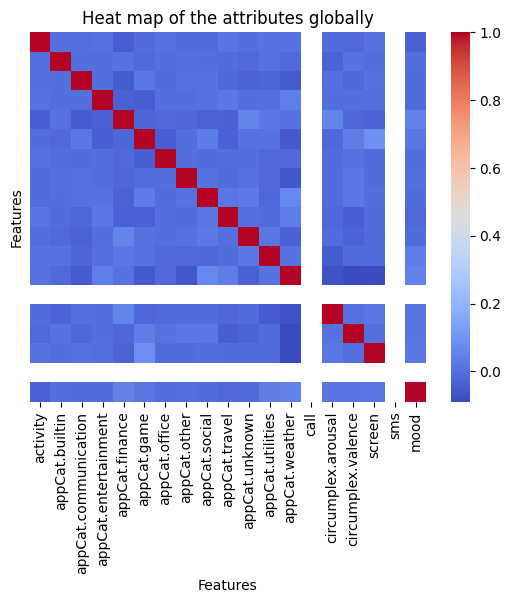

In [14]:

corr_mtx = df_pivoted.corr(numeric_only=True)
print(corr_mtx)

corr_plot = sb.heatmap(corr_mtx, cmap = "coolwarm")
# plt.xticks([df_pivoted.columns])
# plt.tick_params("x", rotation = 45)
plt.yticks([])
plt.xlabel('Features')
plt.ylabel('Features')
plt.title('Heat map of the attributes globally')
plt.show()

In [15]:
corr_mtx.max()

activity                1.0
appCat.builtin          1.0
appCat.communication    1.0
appCat.entertainment    1.0
appCat.finance          1.0
appCat.game             1.0
appCat.office           1.0
appCat.other            1.0
appCat.social           1.0
appCat.travel           1.0
appCat.unknown          1.0
appCat.utilities        1.0
appCat.weather          1.0
call                    NaN
circumplex.arousal      1.0
circumplex.valence      1.0
screen                  1.0
sms                     NaN
mood                    1.0
dtype: float64

Call and sms are not correlating with any other variables cause they are just 1s. 

#### 1A.5 Relationships between mood and attribute

This can be seen above, mood does not correlate highly with any of the other variables. 

#### 1A.6 Split dataset into participant data????

#### 1A Summary

There are 276911 instances (without headers) in the raw data and 5 colomns
- 27 participants

Amount of measures in time differs for the participants. Ranging from 2270 times, to 21298 times

19 attributes in the 'variable' column

### 1B: Data cleaning

First remove the outliers

The outliers are:
- appCat.builtin: three values: -82798.871 and -44.689 and -1.218
- appCat.entertainment: -0.011

I think they all need to be removed? Or we could choose to make them zero, but I think in the case of -82798.871 that is weird so maybe it would be better to just remove all of these.

In [16]:
df_mood = pd.read_csv('dataset_mood_smartphone.csv')

# remove unusual instances before we do correlation testing
to_remove = [-82798.871, -44.689, -1.218, -0.011]

# check if these values occur only once
for value in to_remove:
    count = df_mood["value"].value_counts().get(value, 0)
    print(f"{value} appears {count} time(s)")


df_mood_filt = df_mood[~df_mood["value"].isin(to_remove)]
df_mood_filt

-82798.871 appears 1 time(s)
-44.689 appears 1 time(s)
-1.218 appears 1 time(s)
-0.011 appears 1 time(s)


,Unnamed: 0,id,time,variable,value
0,1,AS14.01,2014-02-26 13:00:00.000,mood,6.000
1,2,AS14.01,2014-02-26 15:00:00.000,mood,6.000
2,3,AS14.01,2014-02-26 18:00:00.000,mood,6.000
3,4,AS14.01,2014-02-26 21:00:00.000,mood,7.000
4,5,AS14.01,2014-02-27 09:00:00.000,mood,6.000
...,...,...,...,...,...
376907,2770399,AS14.30,2014-04-11 07:51:16.948,appCat.weather,8.032
376908,2772465,AS14.30,2014-04-19 11:00:32.747,appCat.weather,3.008
376909,2774026,AS14.30,2014-04-26 10:19:07.434,appCat.weather,7.026
376910,2774133,AS14.30,2014-04-27 00:44:48.450,appCat.weather,23.033


#### 1B.1 Imputing missing data

It says: select two approaches to imput missing values that are logical for such time series and argue for one of them based on the insights you gain. 

Consider what to do with prolonged periods of missing data in a time series.


['AS14.01', 'AS14.05', 'AS14.06', 'AS14.07', 'AS14.08', 'AS14.09', 'AS14.12', 'AS14.15', 'AS14.16', 'AS14.17', 'AS14.24', 'AS14.25', 'AS14.26', 'AS14.28', 'AS14.33']


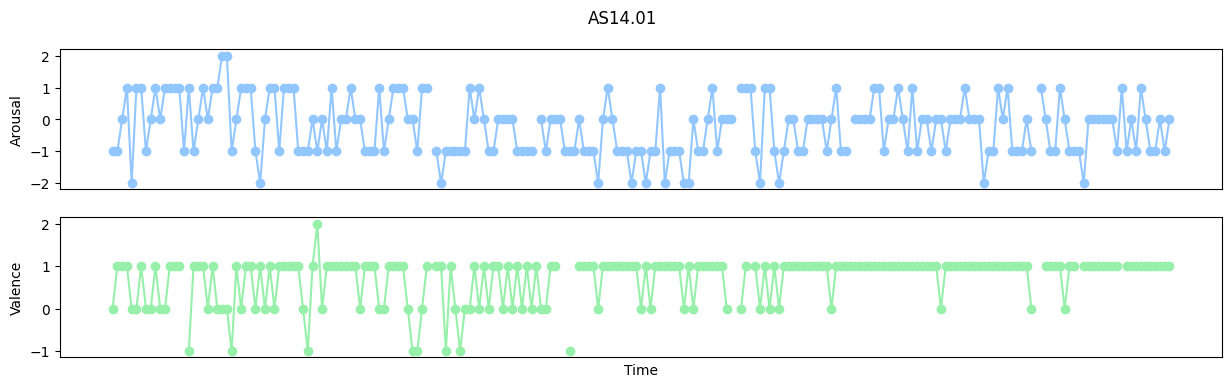

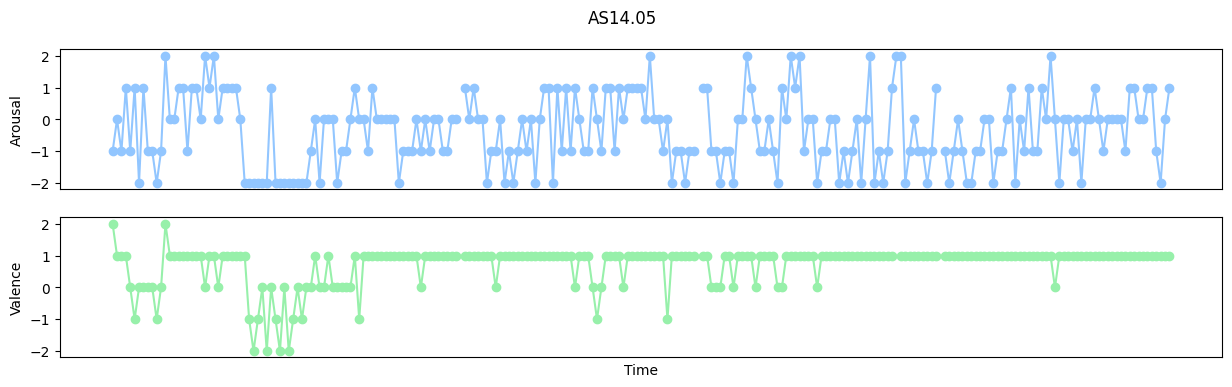

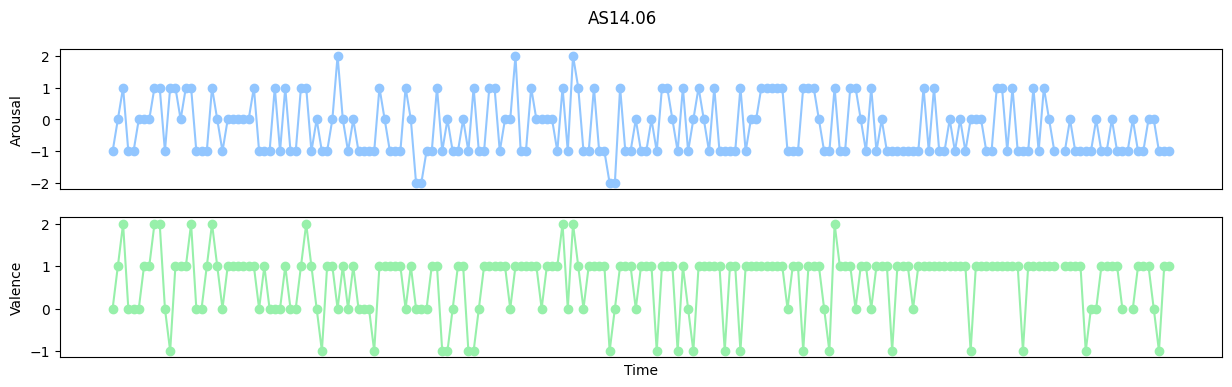

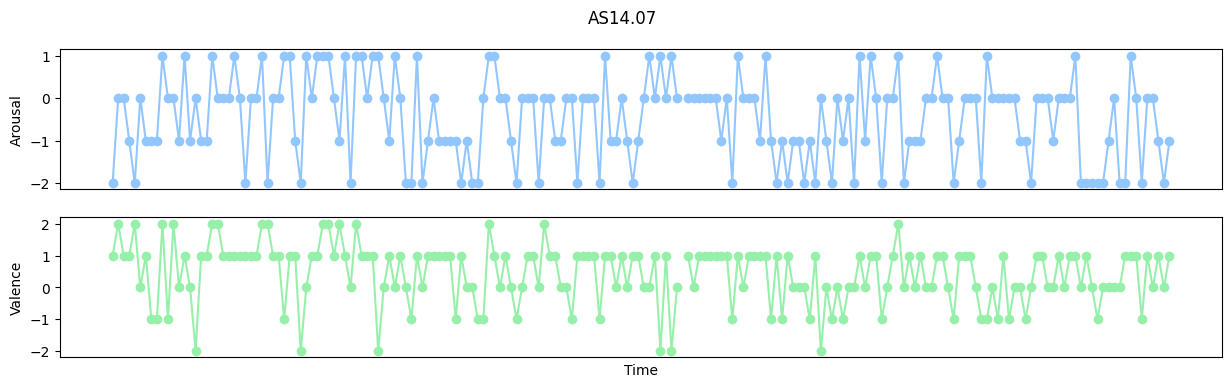

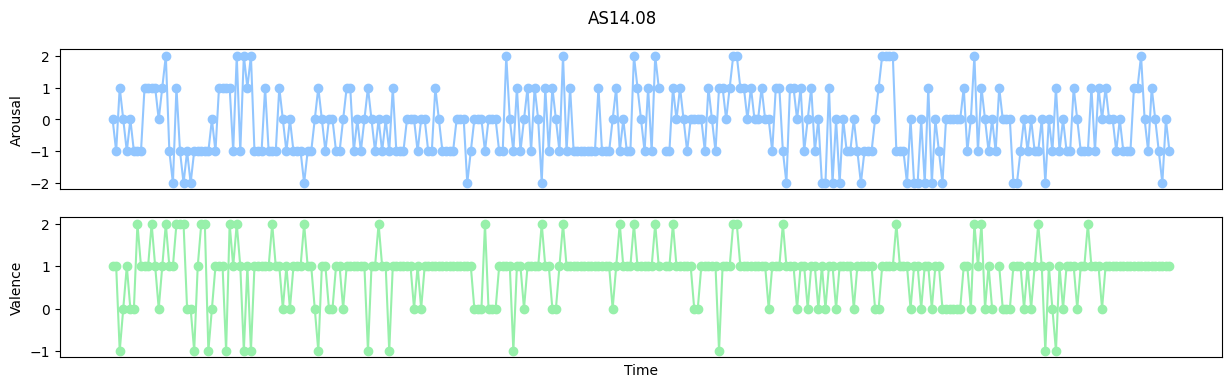

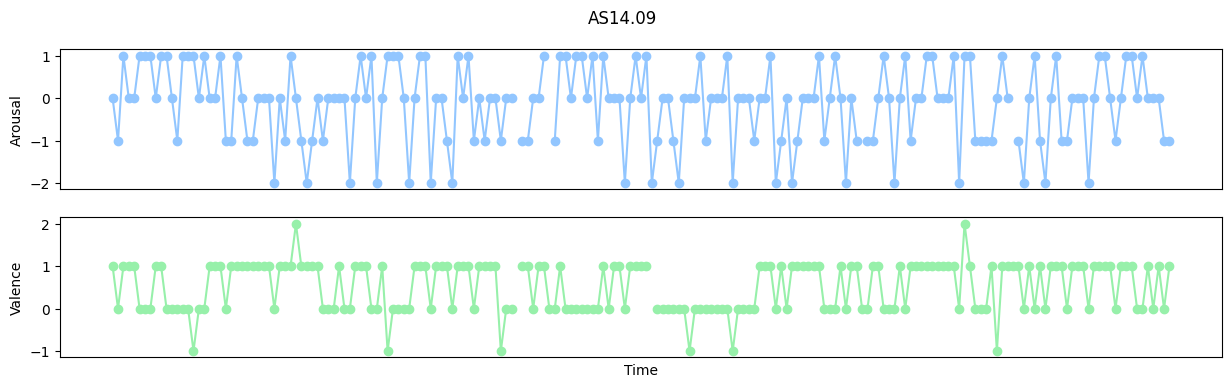

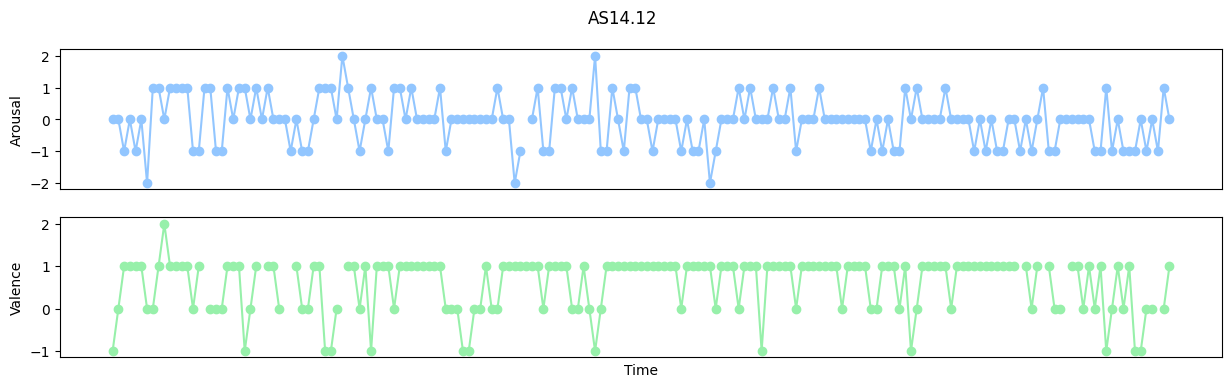

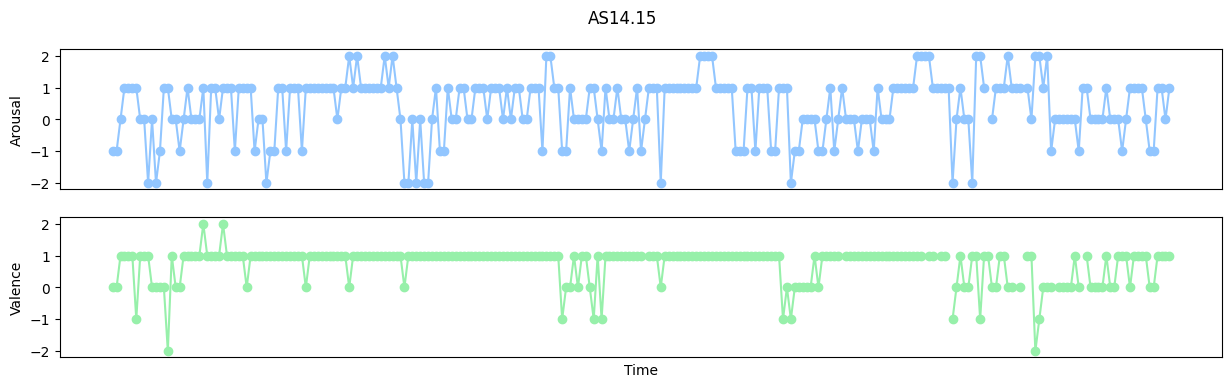

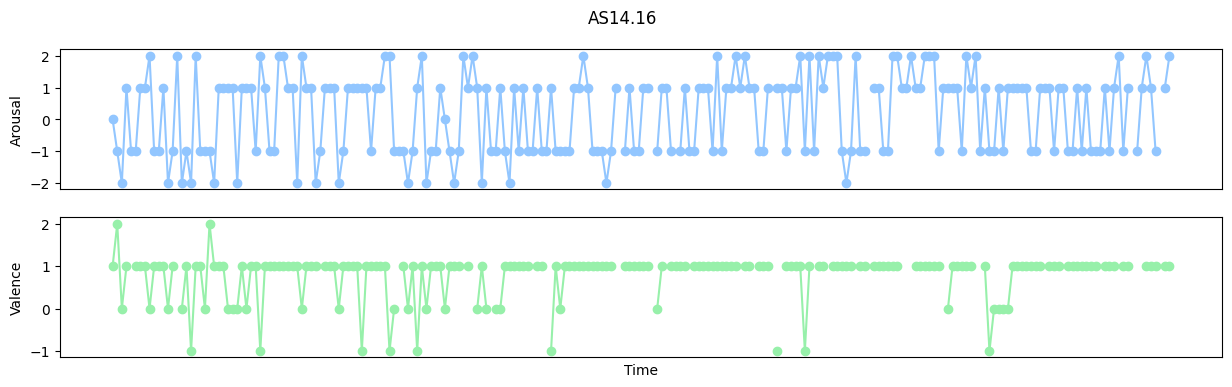

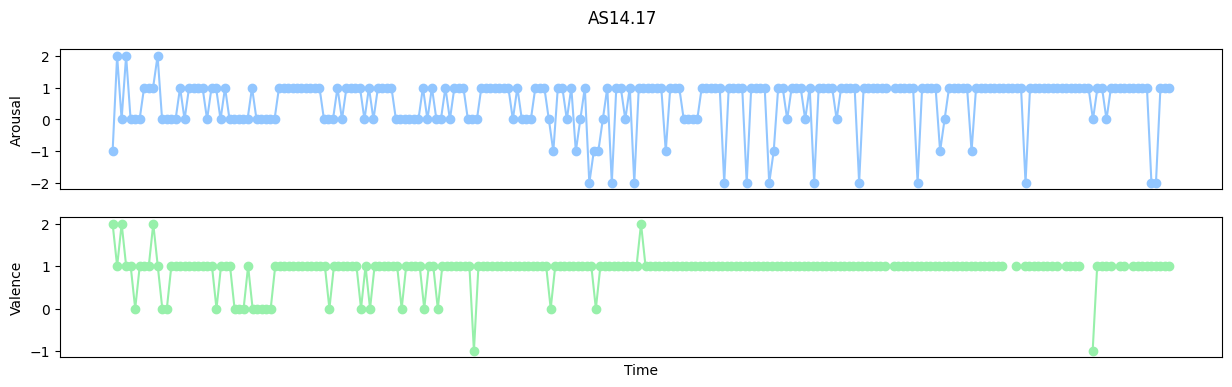

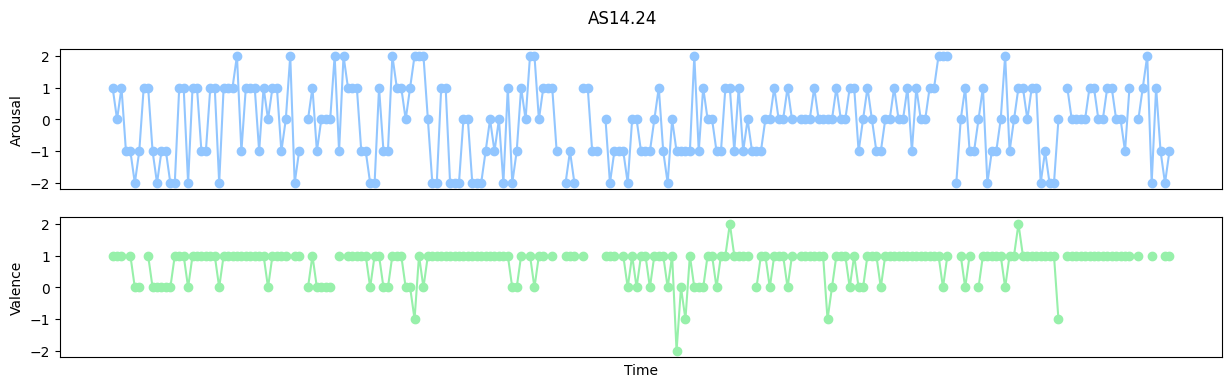

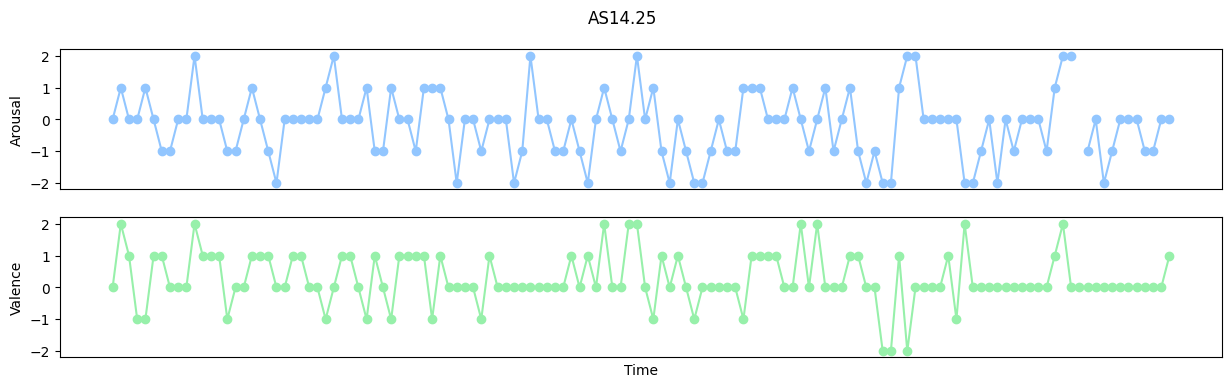

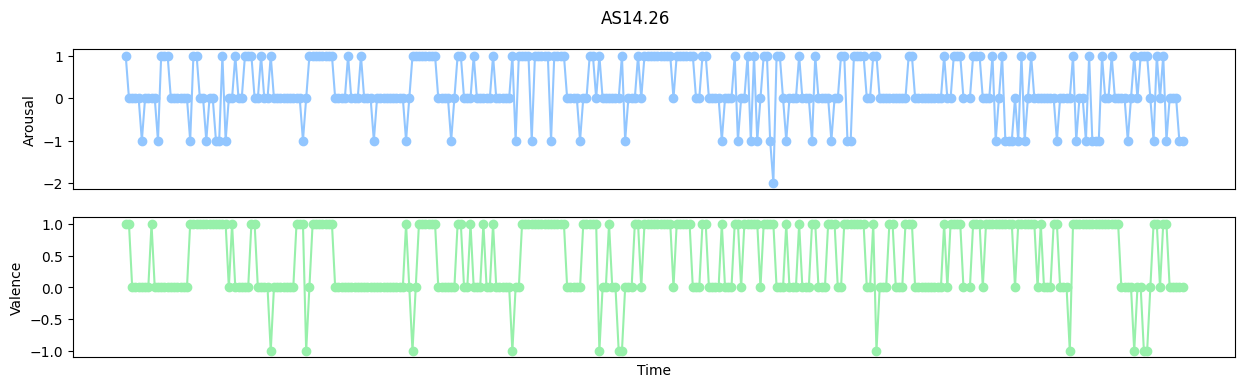

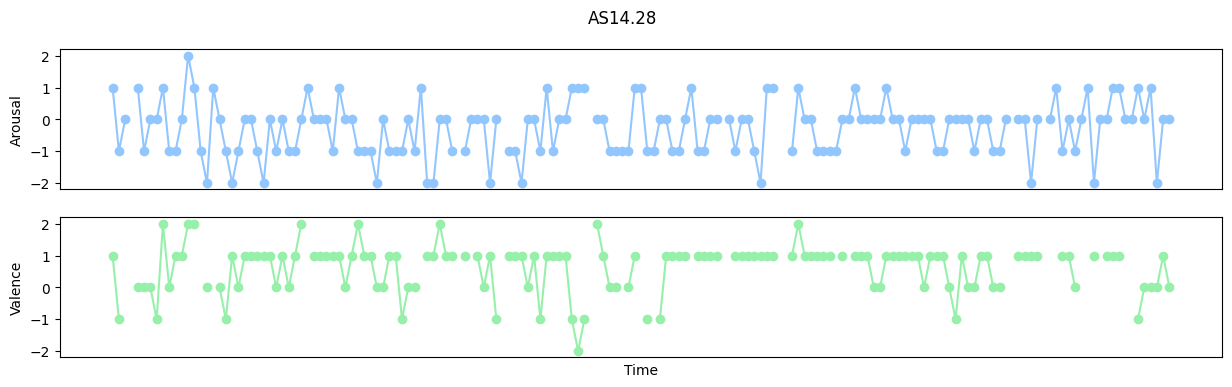

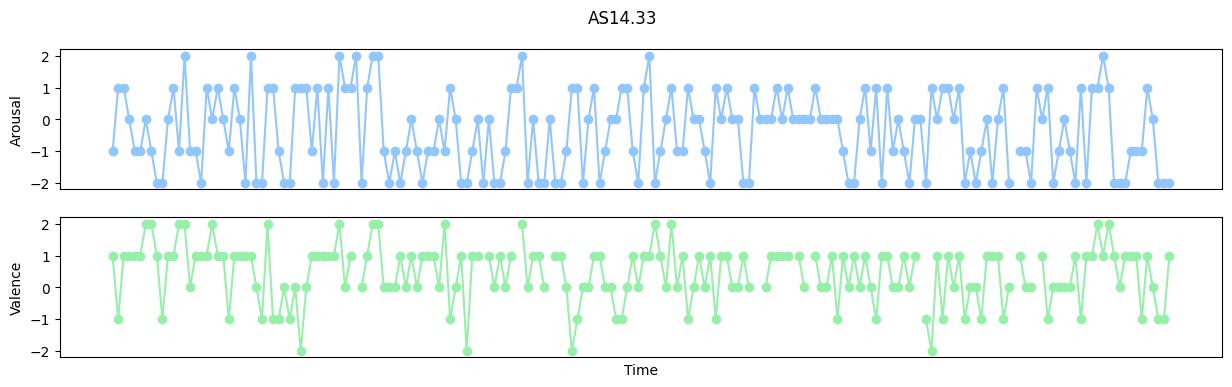

In [17]:
# Because of this last remark, first plot the data for the two variables that are missing values

# find participants for which there is data missing
# missing values per participant
ids = df_mood_filt.id.unique()
ids_withmiss = []

missing_counts = {'Arousal': [], 'Valence': []}

for id in ids:
    #define df for this id
    id_df = df_mood_filt[df_mood_filt.id == id]
    if id_df['value'].isnull().sum() > 0:
        ids_withmiss.append(id)

print(ids_withmiss)

# plot that data (lines?)
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

for id in ids_withmiss:

    id_df = df_mood_filt[df_mood_filt.id == id]
    valence_df = id_df[id_df['variable'] == 'circumplex.valence']
    arousal_df = id_df[id_df['variable'] == 'circumplex.arousal']
    fig1, axs = plt.subplots(2, 1,  figsize=(15, 4))
    axs[0].plot(arousal_df['value'], 'o-', color = colors[0])
    axs[0].set_ylabel("Arousal")
    axs[1].plot(valence_df['value'], 'o-', color = colors[1])
    axs[1].set_ylabel("Valence")
    axs[1].set_xlabel("Time")

    fig1.suptitle(id)


    for ax in axs:
        ax.tick_params(axis='x', which='both', labelbottom=False, bottom=False)
    # plt.show()



# later impute the data and compare



Dataprep:

In [18]:
# We want to impute data only based on that participant

# split df in df_valence_arouse and df_everything_else
df_other = df_mood_filt.loc[(df_mood_filt['variable'] != 'circumplex.arousal') & (df_mood_filt['variable'] != 'circumplex.valence')]

df_val = df_mood_filt.loc[(df_mood_filt['variable'] == 'circumplex.valence')]
df_ar = df_mood_filt.loc[(df_mood_filt['variable'] == 'circumplex.arousal')]

##### 1B.1.1 KNN imputer

KNN
https://www.sciencedirect.com/science/article/pii/S2352914823002289

In [19]:
from sklearn.impute import KNNImputer

# First find the missing values for each participant, and impute the data
def impute_KNN(df, valid = [-2.0, -1.0, 0.0, 1.0, 2.0]):
    new_df = pd.DataFrame(columns = df.columns)
    for id in df.id.unique():
        id_df = df[df.id == id]
        # check whether or not there are missing values here
        if id_df.value.isnull().sum() > 0:
            # impute data
            values = np.array(id_df.value.tolist()).reshape(-1,1)
            # print(values)
            knn = KNNImputer(n_neighbors=2, weights="uniform")
            X = knn.fit_transform(values)
            X = X.reshape(1, -1)[0]
            # print(X)

            for i in range(len(X)):
                if X[i] not in valid:
                    X[i] = float(round(X[i]))
            id_df.value = X
            id_df_new = id_df

        else:
            id_df_new = id_df

        new_df = pd.concat([new_df, id_df_new])
    
    return new_df


# Impute the values and get the new and imputed dataframes (for valence and arousal only)
df_imputed_val = impute_KNN(df_val)
df_imputed_ar = impute_KNN(df_ar)

# Concatenate to one dataframe
df_KNN_imputed = pd.concat([df_other, df_imputed_val, df_imputed_ar])



##### 1B.1.2 Median

In [20]:
from sklearn.impute import SimpleImputer

# First find the missing values for each participant, and impute the data
def impute_simple(df, valid = [-2.0, -1.0, 0.0, 1.0, 2.0]):
    new_df = pd.DataFrame(columns = df.columns)
    for id in df.id.unique():
        id_df = df[df.id == id]

        # check whether or not there are missing values here
        if id_df.value.isnull().sum() > 0:

            # impute data
            values = np.array(id_df.value.tolist()).reshape(-1,1)
            
            simp = SimpleImputer(strategy = "median")
            values_new = simp.fit_transform(values)
            values_new = values_new.reshape(1, -1)[0]
            
            id_df.value = values_new
            id_df_new = id_df

        else:
            id_df_new = id_df

        new_df = pd.concat([new_df, id_df_new])
    
    return new_df


# Impute the values and get the new and imputed dataframes (for valence and arousal only)
df_imputed_val = impute_simple(df_val)
df_imputed_ar = impute_simple(df_ar)

# Concatenate to one dataframe
df_simple_imputed = pd.concat([df_other, df_imputed_val, df_imputed_ar])



##### Compare these methods

In [21]:
def compare_imputing(df, val_or_ar):

    complete_data = df.dropna()

    masked_data = complete_data.copy()
  
    m_values = masked_data.value
    rng = np.random.default_rng(42)
    mask = rng.random(m_values.shape) < 0.1
    m_values[mask] = np.nan

    masked_data.value = m_values


    # impute
    imputed_simple = impute_simple(masked_data)
    imputed_knn = impute_KNN(masked_data)

    # get correct instances
    true_values = complete_data.value[mask]
    imputed_values_simple = imputed_simple.value[mask]
    imputed_values_knn = imputed_knn.value[mask]

    # calculate accuracy and print

    accuracy_simple = np.mean(imputed_values_simple == true_values)
    print(f'Accuracy Simple imputation, {val_or_ar}: {accuracy_simple:.2%}')
    accuracy_knn = np.mean(imputed_values_knn == true_values)
    print(f'Accuracy KNN imputation, {val_or_ar}: {accuracy_knn:.2%}')
    return

compare_imputing(df_ar, 'Arousal')
compare_imputing(df_val, 'Valence')


Accuracy Simple imputation, Arousal: 39.12%
Accuracy KNN imputation, Arousal: 33.27%
Accuracy Simple imputation, Valence: 66.24%
Accuracy KNN imputation, Valence: 64.21%


Simple imputation is better so we move on with: df_simple_imputed

### 1C: Feature Engineering

In [22]:
df_simple_imputed

# I am removing the 'call' and 'sms' feature cause they are uninformative (they are only 1s)
df_simple_imputed = df_simple_imputed[~df_simple_imputed['variable'].isin(['call', 'sms'])]

In [23]:
# Create separate df for each id
df_dict = {}

for id in df_simple_imputed.id.unique():
    df_dict[id] = df_simple_imputed[df_simple_imputed.id == id]

In [24]:
def separate_date_time(df):
    times = df.time.tolist()

    dates = [time.split(' ')[0] for time in times]
    timemarks = [time.split(' ')[1] for time in times]

    df['dates'] = dates
    df['timemark'] = timemarks

    return df

In [25]:
for id in df_dict.keys():
    df_dict[id] = separate_date_time(df_dict[id])

    # Removing all instances / dates that dont have info on mood

    id_df = df_dict[id]
    initial_ins = len(id_df)

    mood_dates = list(id_df.dates[id_df['variable'] == 'mood'].unique())

    id_df = id_df[id_df['dates'].isin(mood_dates)]
    kept_ins = len(id_df)
    print(id, initial_ins - kept_ins)

    df_dict[id] = id_df




AS14.01 197
AS14.02 656
AS14.03 273
AS14.05 0
AS14.06 406
AS14.07 79
AS14.08 0
AS14.09 0
AS14.12 0
AS14.13 0
AS14.14 68
AS14.15 68
AS14.16 125
AS14.17 217
AS14.19 0
AS14.20 0
AS14.23 2032
AS14.24 215
AS14.25 449
AS14.26 308
AS14.27 325
AS14.28 428
AS14.29 701
AS14.30 0
AS14.31 101
AS14.32 957
AS14.33 845


In [26]:
print(df_dict['AS14.33'].dates)

5449     2014-04-16
5450     2014-04-16
5451     2014-04-16
5452     2014-04-17
5453     2014-04-17
            ...    
11279    2014-05-30
11280    2014-05-30
11281    2014-05-30
11282    2014-05-30
11283    2014-05-31
Name: dates, Length: 15016, dtype: str


In [27]:
# print(df_dict['AS14.33'].timemarks.tolist())

# maybe separate the days
# find mean of attributes during the day
# predict based on that....

# find how many days you would want to based you prediciont of mood on
# we could choose 1 -> 'if screen time of day 3 was like this, what is mood on day 4' or on that same day
# or more -> 'if screen time was like this on day 2, 3, 4, 5, what is mood on day 6'

In [28]:
from datetime import date, timedelta # this next piece of code i copied from claude.ai (sorry)

def find_consecutive_groups(dates: list[str]) -> list[list[str]]:
    """
    Given a list of date strings (YYYY-MM-DD), returns groups of consecutive dates.
    Each group is a list of date strings sorted in ascending order.
    """
    if not dates:
        return []

    # Parse and sort, removing duplicates
    parsed = sorted(set(date.fromisoformat(d) for d in dates))

    groups = []
    current_group = [parsed[0]]

    for i in range(1, len(parsed)):
        if parsed[i] - parsed[i - 1] == timedelta(days=1):
            current_group.append(parsed[i])
        else:
            groups.append(current_group)
            current_group = [parsed[i]]

    groups.append(current_group)

    # Convert back to strings
    return [[str(d) for d in group] for group in groups]


In [29]:
rm_dates = {}

for id in df_dict.keys():
    
    groups = find_consecutive_groups(df_dict[id].dates.tolist())
    if len(groups) > 1:
        print(id)

        for i, group in enumerate(groups, 1):
            print(f"Group {i}: {len(group)} consecutive date(s) → {group[0]} to {group[-1]}")
            print(f"  Dates: {group}")
        print()

rm_dates = {
    'AS14.01' : ['2014-02-26', '2014-02-27'], 
    'AS14.12' : ['2014-03-15'],
    'AS14.17' : ['2014-03-04', '2014-03-05', '2014-03-06', '2014-03-07', '2014-03-08', '2014-03-09', '2014-03-10', '2014-03-11', '2014-03-12', '2014-03-13', '2014-03-14'],
    'AS14.31' : ['2014-05-07', '2014-05-08', '2014-05-09', '2014-05-10', '2014-05-11', '2014-05-12', '2014-05-13', '2014-05-14', '2014-05-15', '2014-05-17']
}

AS14.01
Group 1: 2 consecutive date(s) → 2014-02-26 to 2014-02-27
  Dates: ['2014-02-26', '2014-02-27']
Group 2: 45 consecutive date(s) → 2014-03-21 to 2014-05-04
  Dates: ['2014-03-21', '2014-03-22', '2014-03-23', '2014-03-24', '2014-03-25', '2014-03-26', '2014-03-27', '2014-03-28', '2014-03-29', '2014-03-30', '2014-03-31', '2014-04-01', '2014-04-02', '2014-04-03', '2014-04-04', '2014-04-05', '2014-04-06', '2014-04-07', '2014-04-08', '2014-04-09', '2014-04-10', '2014-04-11', '2014-04-12', '2014-04-13', '2014-04-14', '2014-04-15', '2014-04-16', '2014-04-17', '2014-04-18', '2014-04-19', '2014-04-20', '2014-04-21', '2014-04-22', '2014-04-23', '2014-04-24', '2014-04-25', '2014-04-26', '2014-04-27', '2014-04-28', '2014-04-29', '2014-04-30', '2014-05-01', '2014-05-02', '2014-05-03', '2014-05-04']

AS14.03
Group 1: 46 consecutive date(s) → 2014-03-21 to 2014-05-05
  Dates: ['2014-03-21', '2014-03-22', '2014-03-23', '2014-03-24', '2014-03-25', '2014-03-26', '2014-03-27', '2014-03-28', '2014-0

Removing those dates:

In [31]:
for id in df_dict.keys():
    if id in rm_dates.keys():
        id_df = df_dict[id]
        id_df_new = id_df[~id_df['dates'].isin([rm_dates[id]])]
        df_dict[id] = id_df_new

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

Valence and arousal are very important to predict mood (https://ieeexplore.ieee.org/document/9320230)
Valence = the pleasantness of the emotions someone experiences
Arousal = The intensity of that emotion

so say you are frustrated, that is low valence and low arousal, But angry/furious would be low valance, high arousal.
https://neurodivergentinsights.com/arousal-valence-model/?srsltid=AfmBOopmA58E4BpfRKM-RYsMTy-mCcMTMpB0HgygDPyLdicpQZKMT_bS

#### Final dataframe

id        day_span     value_daypan      target_day         avg_mood_d6     std_mood_6        etc
AS14      day 1-6      value day 1-5     day6               value           value

targets:
average mood per day
std mood per day
trend per day

attributes
average mood per 5 days
std mood per 5 days
trend per 5 days

average valence per 5 days
std valence per 5 days
trend valence per 5 days

average arousal per 5 days
std arousal per 5 days
trend arousal per 5 days

average screentime per 5 days
std screentime per 5 days
trend screentime per 5 days

In [ ]:
this = 'circumplex.valence'
'valence' in this

True

In [ ]:
from sklearn.linear_model import LinearRegression

def get_attribute_string(attribute :str) -> str:
    if 'circumplex' in attribute:
        _, att = attribute.split('.')
        return att
    else:
        return attribute
    
def metrics_for_att(df_attribute) -> list[float]:
    mean = np.mean(df_attribute.value)
    std= np.std(df_attribute.value)
    
    X = np.arange(len(df_attribute.value)).reshape(-1, 1)
    y = np.array(df_attribute.value)
    # print(y)
    model = LinearRegression()
    model.fit(X, y)
    trend = model.coef_[0]

    return [mean, std, trend]

In [ ]:
df_this = df_dict['AS14.08']
df_this

,Unnamed: 0,id,time,variable,value,dates,timemark
1238,1239,AS14.08,2014-03-05 15:00:00.000,mood,7.0,2014-03-05,15:00:00.000
1239,1240,AS14.08,2014-03-05 17:00:00.000,mood,7.0,2014-03-05,17:00:00.000
1240,1241,AS14.08,2014-03-05 20:00:00.000,mood,5.0,2014-03-05,20:00:00.000
1241,1242,AS14.08,2014-03-06 09:00:00.000,mood,7.0,2014-03-06,09:00:00.000
1242,1243,AS14.08,2014-03-06 12:00:00.000,mood,8.0,2014-03-06,12:00:00.000
...,...,...,...,...,...,...,...
7175,7176,AS14.08,2014-05-04 18:00:00.000,circumplex.arousal,0.0,2014-05-04,18:00:00.000
7176,7177,AS14.08,2014-05-04 21:00:00.000,circumplex.arousal,-1.0,2014-05-04,21:00:00.000
7177,7178,AS14.08,2014-05-05 09:00:00.000,circumplex.arousal,-2.0,2014-05-05,09:00:00.000
7178,7179,AS14.08,2014-05-05 12:00:00.000,circumplex.arousal,0.0,2014-05-05,12:00:00.000


In [ ]:
attributes = ['mood', 'circumplex.valence', 'circumplex.arousal', 'screen']
time_window = 5



for par_id in df_dict.keys():
    print(par_id)
    if par_id in ['AS14.08', 'AS14.09', 'AS14.17', 'AS14.20', 'AS14.26', 'AS14.31']:
        print('skip')
        continue
    
    # per participant
    df_original = df_dict[par_id]
    
    n_dates = len(df_original.dates.unique())

    sorted_dates = sorted(df_original.dates.unique())

    # initialize dict
    id_dict = {
        'id' : [],
        't' : [], # for example day 1-5
        'avg_mood_t' : [], #ts = dayspan, note that this is day 1-5
        'std_mood_t' : [],
        'trend_mood_t': [],

        'avg_valence_t' : [], 
        'std_valence_t' : [],
        'trend_valence_t': [],

        'avg_arousal_t' : [], 
        'std_arousal_t' : [],
        'trend_arousal_t': [],

        'avg_screen_t' : [], 
        'std_screen_t' : [],
        'trend_screen_t': [],

        'target_day' : [], # day 6
        'avg_mood_target' : [], #this is only over one day
        'std_mood_target' : [],
        'trend_mood_target': [],
    }


    for i in range(n_dates - time_window):
        
        # first select data from the range of 5 days
        date_range = sorted_dates[i : i + time_window]
        df_date_span = df_original[df_original['dates'].isin(date_range)]

        id_dict['id'].append(par_id)
        id_dict['t'].append(f'day {i + 1}-{i + time_window}')

        for attribute in attributes:
            # print(attribute, 'timespan')
            df_attribute = df_date_span[df_date_span['variable'] == attribute]
            att_name = get_attribute_string(attribute=attribute)
            # print(df_attribute)

            avg, std, trend = metrics_for_att(df_attribute=df_attribute)

            dict_keynames = [f'avg_{att_name}_t', f'std_{att_name}_t', f'trend_{att_name}_t']

            id_dict[dict_keynames[0]].append(avg)
            id_dict[dict_keynames[1]].append(std)
            id_dict[dict_keynames[2]].append(trend)

        # get target values
        print('target now', i + time_window + 1)
        target_date = sorted_dates[i + time_window]
        df_target_date = df_original[df_original['dates'].isin([target_date])]
        # print(df_target_date)

        df_attribute = df_target_date[df_target_date['variable'] == 'mood']
        # print(df_attribute)
        avg, std, trend = metrics_for_att(df_attribute=df_attribute)

        id_dict['target_day'].append(f'day {i + time_window + 1}')
        id_dict['avg_mood_target'].append(avg)
        id_dict['std_mood_target'].append(std)
        id_dict['trend_mood_target'].append(trend)


    
        
    par_df = pd.DataFrame(id_dict)
    

    par_df.to_csv(f'dfs_per_participant/df_{par_id}.csv', index = False)


AS14.01
target now 6
target now 7
target now 8
target now 9
target now 10
target now 11
target now 12
target now 13
target now 14
target now 15
target now 16
target now 17
target now 18
target now 19
target now 20
target now 21
target now 22
target now 23
target now 24
target now 25
target now 26
target now 27
target now 28
target now 29
target now 30
target now 31
target now 32
target now 33
target now 34
target now 35
target now 36
target now 37
target now 38
target now 39
target now 40
target now 41
target now 42
target now 43
target now 44
target now 45
target now 46
target now 47
AS14.02
target now 6
target now 7
target now 8
target now 9
target now 10
target now 11
target now 12
target now 13
target now 14
target now 15
target now 16
target now 17
target now 18
target now 19
target now 20
target now 21
target now 22
target now 23
target now 24
target now 25
target now 26
target now 27
target now 28
target now 29
target now 30
target now 31
target now 32
target now 33
target now 3

dates = [1, 2, 3, 4, 5, 6, 7]
first it: day =  1-5 | target day = 6 -> i = 0 (len(dates))
second it: day =  2-6 | target day = 7 -> i = 1  = len(dates) - time_window (i_target = 6 -> len(dates) - time_window)

In [ ]:
this = [1, 2, 3, 4, 5, 6, 23, 2,3, 32, 23, 3,2, 3, 2, 32, 32, 3, 23, 3,2 ,3,23, 32, 32, 32,3, 2,3, 23, 3]
i = 0
time_window = 5
print(this[i : i + time_window])

print(f'day {i + 1}-{i  + time_window}')
print(this[i + time_window])

[1, 2, 3, 4, 5]
day 1-5
6
